# Capstone Project: California House Price Prediction

**Project type:** regression  
**Goal:** predict a California district's median house value, measured in $100,000s.

This notebook uses a reproducible train/validation/test workflow. The test set stays untouched until the final model has been selected.

## 1. Imports and reproducibility

The notebook does not import or call SciPy directly. Scikit-learn handles the estimators and NumPy handles the reported metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)
print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


## 2. Load and validate the data source

`fetch_california_housing` downloads `https://ndownloader.figshare.com/files/5976036` on first use. During that download, scikit-learn checks the archive against its registered SHA-256 checksum `aaa5c9a6afe2225cc2aed2723682ae403280c4a3695a2ddda4ffb5d8215ea681`; later runs may reuse scikit-learn's local cache. See the [dataset documentation](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset). The explicit checks below validate the frame actually loaded on every run.

We do not silently accept an unexpected download or schema: the next cell checks row count, exact columns, missing values, numeric finiteness, and target bounds before modeling.

In [2]:
try:
    housing = fetch_california_housing(as_frame=True)
except OSError as exc:
    raise RuntimeError(
        "California Housing is not cached. Connect to the network for the first run, "
        "then rerun this cell so scikit-learn can download and verify the dataset."
    ) from exc

df = housing.frame.copy()
expected_features = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude",
]
expected_columns = expected_features + ["MedHouseVal"]

if df.shape != (20_640, 9):
    raise ValueError(f"Unexpected dataset shape: {df.shape}")
if df.columns.tolist() != expected_columns:
    raise ValueError(f"Unexpected dataset columns: {df.columns.tolist()}")
if df.isna().any().any():
    raise ValueError("Dataset contains unexpected missing values")
if not np.isfinite(df.to_numpy()).all():
    raise ValueError("Dataset contains non-finite values")
if not df["MedHouseVal"].between(0, 5.00001).all():
    raise ValueError("Target is outside the documented range")

print("Validated dataset shape:", df.shape)
df.head()

Validated dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Split before exploration

The 20% test set is locked away first. A second split creates a validation set for model selection. All plots, preprocessing fits, and model comparisons below use only training or validation rows; the test rows are evaluated once at the end.

This is a **random row split**. Identical or nearby coordinates can occur in different splits, so the score estimates interpolation to other sampled districts—not generalization to a completely new geographic region. A deployment study for new regions should instead group districts into longitude/latitude grid cells and keep entire spatial groups in one split.

In [3]:
X = df[expected_features]
y = df["MedHouseVal"]

X_development, X_test, y_development, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development, y_development, test_size=0.25, random_state=RANDOM_SEED
)

split_indexes = [set(X_train.index), set(X_validation.index), set(X_test.index)]
if not (
    split_indexes[0].isdisjoint(split_indexes[1])
    and split_indexes[0].isdisjoint(split_indexes[2])
    and split_indexes[1].isdisjoint(split_indexes[2])
):
    raise ValueError("Train, validation, and test row indexes overlap")
print("Train / validation / test rows:", len(X_train), len(X_validation), len(X_test))

Train / validation / test rows: 12384 4128 4128


## 4. Training-set exploration

The capped target at 5 means `$500,000 or more`, a limitation to remember when interpreting predictions.

,count,mean,std,min,25%,50%,75%,max
MedInc,12384.0,3.870,1.888,0.500,2.562,3.552,4.740,15.000
HouseAge,12384.0,28.586,12.608,1.000,18.000,29.000,37.000,52.000
AveRooms,12384.0,5.412,2.077,0.889,4.443,5.223,6.046,61.812
AveBedrms,12384.0,1.093,0.362,0.375,1.006,1.050,1.101,11.411
Population,12384.0,1427.290,1140.979,3.000,790.000,1170.000,1726.000,35682.000
AveOccup,12384.0,3.033,7.074,0.692,2.427,2.816,3.280,599.714
Latitude,12384.0,35.642,2.131,32.560,33.930,34.260,37.720,41.950
Longitude,12384.0,-119.580,2.005,-124.350,-121.800,-118.500,-118.010,-114.310
MedHouseVal,12384.0,2.068,1.151,0.150,1.198,1.798,2.646,5.000


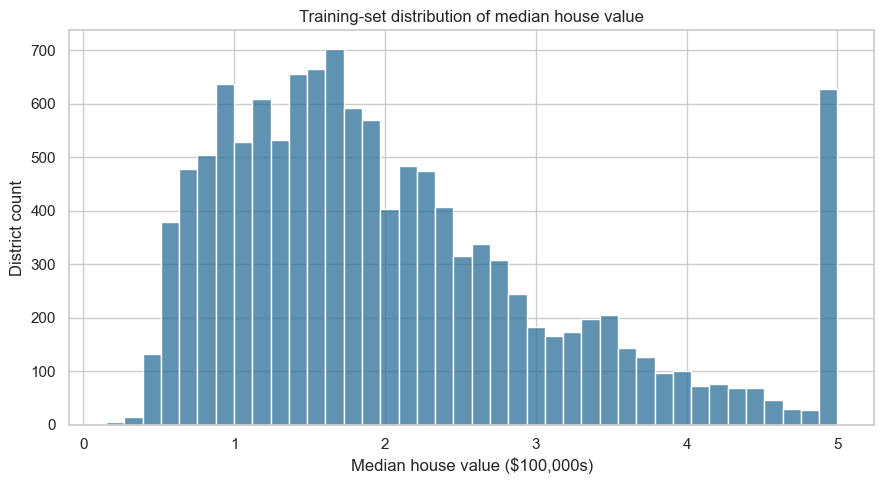

In [4]:
train_df = X_train.assign(MedHouseVal=y_train)
display(train_df.describe().T.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(train_df["MedHouseVal"], bins=40, color="#2a6f97", ax=ax)
ax.set(
    title="Training-set distribution of median house value",
    xlabel="Median house value ($100,000s)",
    ylabel="District count",
)
plt.tight_layout()
plt.show()

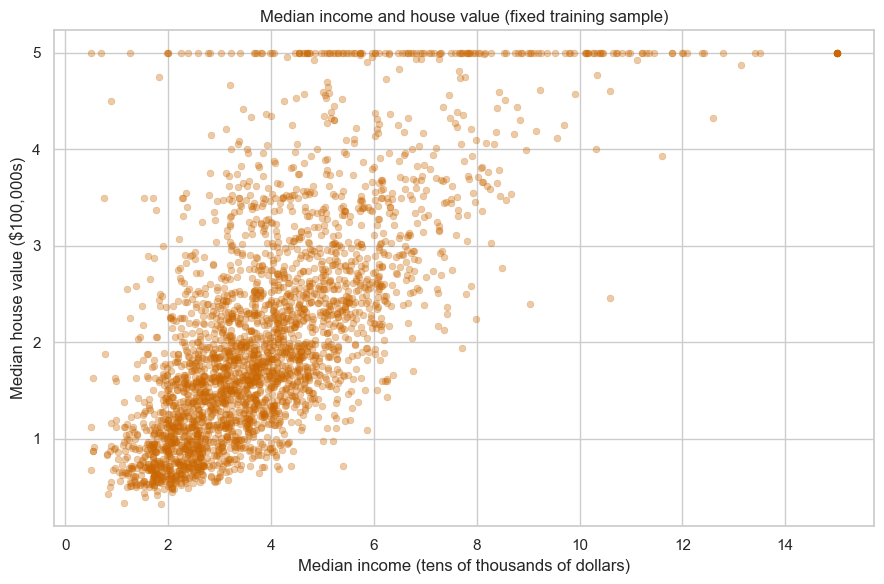

In [5]:
plot_sample = train_df.sample(n=3_000, random_state=RANDOM_SEED)
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=plot_sample, x="MedInc", y="MedHouseVal",
    alpha=0.35, s=24, color="#ca6702", edgecolor=None, ax=ax,
)
ax.set(
    title="Median income and house value (fixed training sample)",
    xlabel="Median income (tens of thousands of dollars)",
    ylabel="Median house value ($100,000s)",
)
plt.tight_layout()
plt.show()

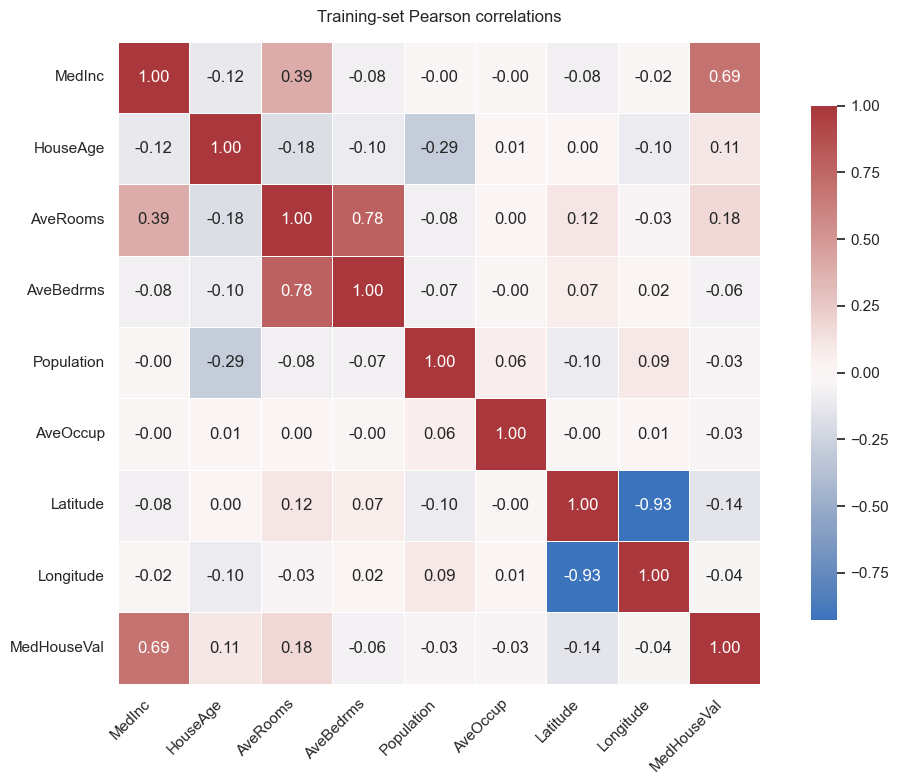

In [6]:
correlations = train_df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    correlations, annot=True, fmt=".2f", cmap="vlag", center=0,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("Training-set Pearson correlations", pad=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Baseline and candidate models

The median predictor is a necessary reality check. The linear model uses a `Pipeline`, so `StandardScaler` learns means and standard deviations from the training split only. The tree does not need scaling. Both candidates and their hyperparameters are declared before validation scoring.

In [7]:
def regression_metrics(actual, predicted):
    actual_array = np.asarray(actual, dtype=float)
    predicted_array = np.asarray(predicted, dtype=float)
    residual = actual_array - predicted_array
    return {
        "RMSE": float(np.sqrt(np.mean(residual ** 2))),
        "MAE": float(np.mean(np.abs(residual))),
        "R2": float(1 - np.sum(residual ** 2) / np.sum((actual_array - actual_array.mean()) ** 2)),
    }

models = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Linear regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Decision tree (depth 8)": DecisionTreeRegressor(
        max_depth=8, min_samples_leaf=10, random_state=RANDOM_SEED
    ),
}

validation_rows = []
fitted_models = {}
for name, model in models.items():
    fitted = clone(model).fit(X_train, y_train)
    fitted_models[name] = fitted
    validation_rows.append({
        "Model": name,
        **regression_metrics(y_validation, fitted.predict(X_validation)),
    })

validation_results = (
    pd.DataFrame(validation_rows).set_index("Model").sort_values("RMSE")
)
validation_results.round(3)

,RMSE,MAE,R2
Model,,,
Decision tree (depth 8),0.636,0.445,0.706
Linear regression,0.728,0.533,0.614
Median baseline,1.206,0.897,-0.059


## 6. Select and diagnose on validation data, then evaluate once on test data

Selection and residual diagnostics use validation data only. After those decisions are complete, the selected pipeline is freshly refit on the combined training and validation rows. The test set then produces final numerical metrics once; it is considered consumed and must not guide another iteration.

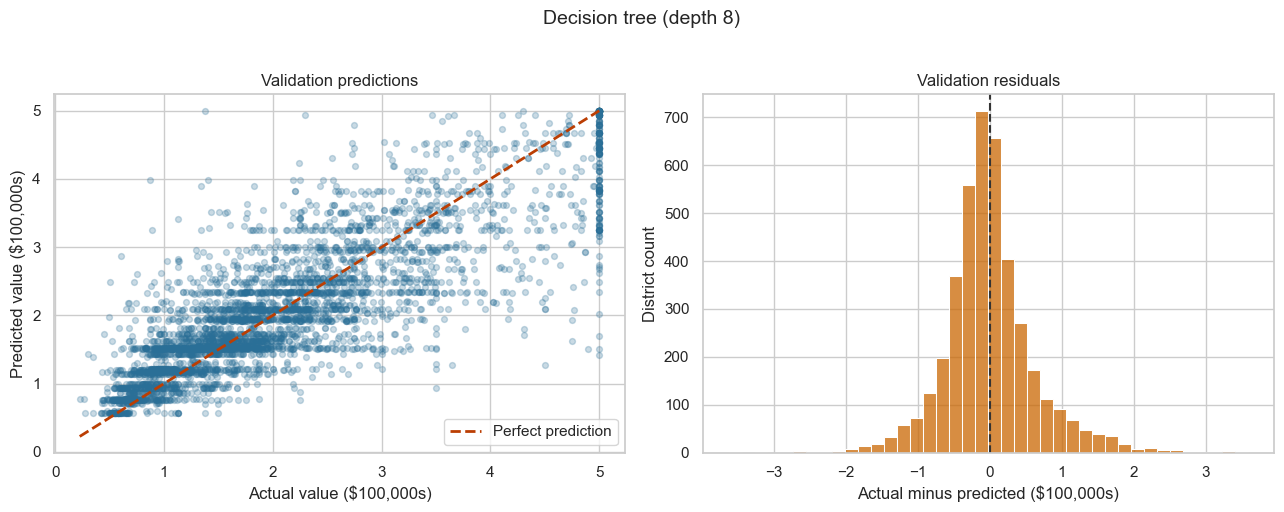

In [8]:
selected_name = validation_results.index[0]
validation_predictions = fitted_models[selected_name].predict(X_validation)
validation_residuals = np.asarray(y_validation) - validation_predictions

figure, axes = plt.subplots(1, 2, figsize=(13, 5))
limits = [
    min(y_validation.min(), validation_predictions.min()),
    max(y_validation.max(), validation_predictions.max()),
]
axes[0].scatter(y_validation, validation_predictions, alpha=0.25, s=18, color="#2a6f97")
axes[0].plot(limits, limits, "--", color="#bb3e03", linewidth=2, label="Perfect prediction")
axes[0].set(
    title="Validation predictions",
    xlabel="Actual value ($100,000s)",
    ylabel="Predicted value ($100,000s)",
)
axes[0].legend()

sns.histplot(validation_residuals, bins=40, color="#ca6702", ax=axes[1])
axes[1].axvline(0, linestyle="--", color="#333333", linewidth=1.5)
axes[1].set(
    title="Validation residuals",
    xlabel="Actual minus predicted ($100,000s)",
    ylabel="District count",
)
figure.suptitle(selected_name, fontsize=14, y=1.02)
figure.tight_layout()
plt.show()

In [9]:
selected_model = clone(models[selected_name]).fit(X_development, y_development)
test_predictions = selected_model.predict(X_test)
test_metrics = pd.Series(regression_metrics(y_test, test_predictions), name="Final test score")

print("Selected model:", selected_name)
print("The test set is now consumed; do not tune the model from these numbers.")
display(test_metrics.to_frame().round(3))

Selected model: Decision tree (depth 8)
The test set is now consumed; do not tune the model from these numbers.


,Final test score
RMSE,0.644
MAE,0.447
R2,0.683


## 7. Conclusions

The following summary is generated from the saved run rather than typed from an earlier experiment. Remember that the target is capped, so the model cannot learn variation above $500,000 from this dataset.

In [10]:
strongest_feature = (
    correlations["MedHouseVal"].drop("MedHouseVal").abs().idxmax()
)
print(f"1. Best validation model: {selected_name}.")
print(f"2. Test RMSE: {test_metrics['RMSE']:.3f} ($100,000s).")
print(f"3. Strongest absolute training-set correlation with the target: {strongest_feature}.")
print(f"4. Mean validation residual: {validation_residuals.mean():.3f}; inspect the validation plots for structure.")
print("5. The random-row score does not measure new-region generalization; use spatial group splits for that goal.")
print("6. The test set has been consumed. Future tuning requires a new untouched test set.")

1. Best validation model: Decision tree (depth 8).
2. Test RMSE: 0.644 ($100,000s).
3. Strongest absolute training-set correlation with the target: MedInc.
4. Mean validation residual: -0.002; inspect the validation plots for structure.
5. The random-row score does not measure new-region generalization; use spatial group splits for that goal.
6. The test set has been consumed. Future tuning requires a new untouched test set.
